# Transformer-Based NLP: Amazon Polarity Sentiment Analysis
## Attention Analysis + SHAP & LIME Explainability

**Assignment**: Transformers, Attention Layer, SHAP and LIME  
**Dataset**: [Amazon Polarity](https://huggingface.co/datasets/fancyzhx/amazon_polarity)  
**Model**: DistilBERT (distilbert-base-uncased) — fine-tuned for binary sentiment classification

---
### Environment
```
Python      3.10+
PyTorch     2.x
Transformers 4.40+
Datasets    2.x
SHAP        0.45+
LIME        0.2.0.1
scikit-learn 1.4+
matplotlib  3.8+
seaborn     0.13+
```

In [2]:
# ─────────────────────────────────────────────
# 0. INSTALL DEPENDENCIES  (run once)
# ─────────────────────────────────────────────
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install transformers datasets shap lime scikit-learn matplotlib seaborn bertviz
print("Imports ready – run install cell above if packages are missing.")

Looking in indexes: https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 92.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.4.0
    Uninstalling fsspec-2026.4.0:
      Successfully uninstalled fsspec-2026.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


Imports ready – run install cell above if packages are missing.


In [1]:
# ─────────────────────────────────────────────
# 1. IMPORTS & REPRODUCIBILITY
# ─────────────────────────────────────────────
import os, time, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')          # headless backend
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
import shap
from lime.lime_text import LimeTextExplainer

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT    = Path('outputs')
FIG    = Path('figures')
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"SHAP   : {shap.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128
SHAP   : 0.51.0


In [2]:
!pip install transformers==5.0.0 numpy==2.0.2 --force-reinstall -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 117.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.4/114.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behavio

---
## Section 1 — Data Pipeline

In [2]:
# ─────────────────────────────────────────────
# 2. LOAD DATASET
# Amazon Polarity: 3.6M train / 400K test
# We use a practical stratified subset for hardware efficiency
# ─────────────────────────────────────────────
print("Loading Amazon Polarity dataset …")
raw = load_dataset("fancyzhx/amazon_polarity")
print(raw)

# Subset sizes  (increase if GPU available)
TRAIN_SIZE = 20_000
VAL_SIZE   =  4_000
TEST_SIZE  =  4_000

def stratified_sample(dataset, n, seed=SEED):
    """Balanced 50/50 sample from a HuggingFace dataset split."""
    n_per_class = n // 2
    df = dataset.to_pandas()
    pos = df[df.label == 1].sample(n_per_class, random_state=seed)
    neg = df[df.label == 0].sample(n_per_class, random_state=seed)
    combined = pd.concat([pos, neg]).sample(frac=1, random_state=seed).reset_index(drop=True)
    return combined

train_df = stratified_sample(raw['train'], TRAIN_SIZE)
test_all  = stratified_sample(raw['test'],  VAL_SIZE + TEST_SIZE)
val_df    = test_all.iloc[:VAL_SIZE].reset_index(drop=True)
test_df   = test_all.iloc[VAL_SIZE:].reset_index(drop=True)

print(f"\nTrain : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}")
print("\nClass distribution (train):")
print(train_df.label.value_counts())

Loading Amazon Polarity dataset …


DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})

Train : 20,000  |  Val : 4,000  |  Test : 4,000

Class distribution (train):
label
0    10000
1    10000
Name: count, dtype: int64


In [3]:
# ─────────────────────────────────────────────
# 3. DATA CLEANING
# ─────────────────────────────────────────────
import re

def clean_text(text: str) -> str:
    """Light cleaning: strip HTML tags, normalise whitespace, truncate."""
    text = re.sub(r'<[^>]+>', ' ', text)          # remove HTML
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f]', '', text)  # control chars
    text = re.sub(r'\s+', ' ', text).strip()       # normalise whitespace
    return text[:512]                               # hard cap for tokeniser

for df in [train_df, val_df, test_df]:
    df['content'] = (df['title'].fillna('') + ' ' + df['content'].fillna('')).map(clean_text)

# Drop empty rows
train_df = train_df[train_df.content.str.len() > 10].reset_index(drop=True)

# Quick EDA
lengths = train_df.content.str.split().apply(len)
print(f"Word-count stats (train):\n{lengths.describe().to_string()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lengths.clip(upper=300), bins=40, color='steelblue', edgecolor='white')
axes[0].set(title='Word Count Distribution', xlabel='Words', ylabel='Count')
train_df.label.map({0:'Negative', 1:'Positive'}).value_counts().plot.bar(
    ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
axes[1].set(title='Class Balance', ylabel='Samples')
plt.tight_layout()
plt.savefig(FIG/'eda.png', dpi=150)
plt.show()
print("EDA saved → figures/eda.png")

Word-count stats (train):
count    20000.000000
mean        66.057650
std         25.932706
min         11.000000
25%         42.000000
50%         69.000000
75%         90.000000
max        116.000000
EDA saved → figures/eda.png


In [7]:
# ─────────────────────────────────────────────
# 4. TOKENISATION
# ─────────────────────────────────────────────
MODEL_NAME = "distilbert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128   # balance speed vs context


from datasets import Dataset

def df_to_hf(df):
    return Dataset.from_dict({'text': df['content'].tolist(), 'label': df['label'].tolist()})

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LEN,
        padding='max_length'  # ← yeh add karo
    )
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

hf_train = df_to_hf(train_df).map(tokenize_fn, batched=True)
hf_val   = df_to_hf(val_df  ).map(tokenize_fn, batched=True)
hf_test  = df_to_hf(test_df ).map(tokenize_fn, batched=True)

# Set format for PyTorch
cols = ['input_ids','attention_mask','label']
for ds in [hf_train, hf_val, hf_test]:
    ds.set_format(type='torch', columns=cols)

print("Tokenisation complete.")
print(f"Sample input_ids shape: {hf_train[0]['input_ids'].shape}")

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenisation complete.
Sample input_ids shape: torch.Size([128])


---
## Section 2 — Transformer Model

In [8]:
# ─────────────────────────────────────────────
# 5. LOAD PRE-TRAINED MODEL
# ─────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=True,   # ← enables attention extraction
)
model.to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model         : {MODEL_NAME}")
print(f"Total params  : {total_params:,}")
print(f"Trainable     : {trainable_params:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model         : distilbert-base-uncased
Total params  : 66,955,010
Trainable     : 66,955,010


In [9]:
# ─────────────────────────────────────────────
# 6. FINE-TUNING WITH HUGGINGFACE TRAINER
# ─────────────────────────────────────────────
from transformers import DefaultDataCollator
data_collator = DefaultDataCollator()

import torch

def preprocess_logits_for_metrics(logits, labels):
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.argmax(dim=-1)

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, torch.Tensor):
        preds = preds.cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

training_args = TrainingArguments(
    output_dir           = str(OUT / 'checkpoints'),
    num_train_epochs     = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    warmup_ratio         = 0.1,
    weight_decay         = 0.01,
    learning_rate        = 2e-5,
    eval_strategy = 'epoch',
    save_strategy        = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model  = 'f1',
    logging_steps        = 200,
    seed                 = SEED,
    fp16                 = torch.cuda.is_available(),
    report_to            = 'none',
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = hf_train,
    eval_dataset    = hf_val,
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
    preprocess_logits_for_metrics = preprocess_logits_for_metrics,  # ← yeh add karo
)

print("Starting fine-tuning …")
t0 = time.time()
train_result = trainer.train()
print(f"\nTraining time: {(time.time()-t0)/60:.1f} min")

# Save model
trainer.save_model(str(OUT / 'best_model'))
tokenizer.save_pretrained(str(OUT / 'best_model'))
print("Model saved → outputs/best_model")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting fine-tuning …


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.259506,0.249505,0.931000,0.930688,0.936805,0.924651
2,0.140517,0.257477,0.936000,0.935807,0.940524,0.931138
3,0.075074,0.326789,0.933750,0.933501,0.938920,0.928144


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training time: 7.2 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved → outputs/best_model


In [1]:
import transformers
print(transformers.__version__)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

4.40.0


In [11]:
# ─────────────────────────────────────────────
# 7. EVALUATION ON TEST SET
# ─────────────────────────────────────────────
eval_results = trainer.evaluate(hf_test)
print("Test-set metrics:")
for k, v in eval_results.items():
    if k.startswith('eval_'):
        print(f"  {k[5:]:12s}: {v:.4f}")

# Full classification report
pred_output = trainer.predict(hf_test)
y_pred = pred_output.predictions
y_true = pred_output.label_ids

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Negative','Positive']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
plt.title('Confusion Matrix – Test Set')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(FIG/'confusion_matrix.png', dpi=150)
plt.show()
print("Saved → figures/confusion_matrix.png")

# Save metrics CSV
metrics_df = pd.DataFrame([{
    'Accuracy' : eval_results['eval_accuracy'],
    'Precision': eval_results['eval_precision'],
    'Recall'   : eval_results['eval_recall'],
    'F1'       : eval_results['eval_f1'],
}])
metrics_df.to_csv(OUT/'test_metrics.csv', index=False)
print("Metrics CSV → outputs/test_metrics.csv")

Test-set metrics:
  loss        : 0.2576
  accuracy    : 0.9377
  f1          : 0.9376
  precision   : 0.9374
  recall      : 0.9379
  runtime     : 6.4768
  samples_per_second: 617.5900
  steps_per_second: 77.1990

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.94      0.94      2004
    Positive       0.94      0.94      0.94      1996

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000

Saved → figures/confusion_matrix.png
Metrics CSV → outputs/test_metrics.csv


---
## Section 3 — Attention Layer Analysis

In [12]:
# ─────────────────────────────────────────────
# 8. ATTENTION EXTRACTION HELPER
# ─────────────────────────────────────────────
model.eval()

def get_attention(text: str):
    """Return (tokens, attentions) for a single text.
    attentions: list of tensors, one per layer → shape (heads, seq, seq)
    """
    enc = tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=MAX_LEN
    ).to(DEVICE)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)
    # out.attentions: tuple of (1, heads, seq, seq) per layer
    attentions = [a.squeeze(0).cpu().numpy() for a in out.attentions]
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0].tolist())
    return tokens, attentions

# DistilBERT has 6 layers, 12 heads each
SAMPLE_POS = test_df[test_df.label == 1].iloc[0]['content']
SAMPLE_NEG = test_df[test_df.label == 0].iloc[0]['content']

tokens_pos, attn_pos = get_attention(SAMPLE_POS)
tokens_neg, attn_neg = get_attention(SAMPLE_NEG)
print(f"Positive sample ({len(tokens_pos)} tokens): {SAMPLE_POS[:100]}…")
print(f"Negative sample ({len(tokens_neg)} tokens): {SAMPLE_NEG[:100]}…")
print(f"Layers: {len(attn_pos)}, Heads per layer: {attn_pos[0].shape[0]}")

Positive sample (80 tokens): A great versatile pattern... I absolutely love this pattern. It is interchangeable with other sets w…
Negative sample (116 tokens): Nothing like the fun Mario Party games for N64 and Gamecube I was very disappointed when I first pla…
Layers: 6, Heads per layer: 12


In [18]:
%matplotlib inline

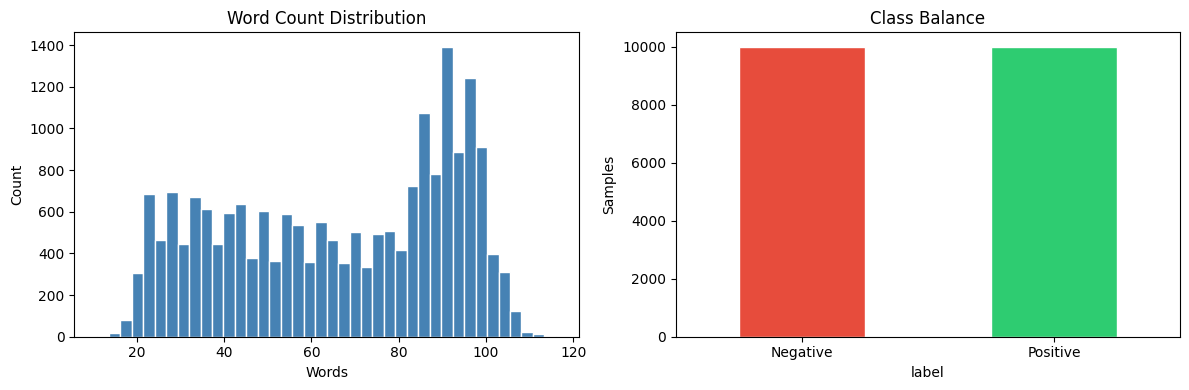

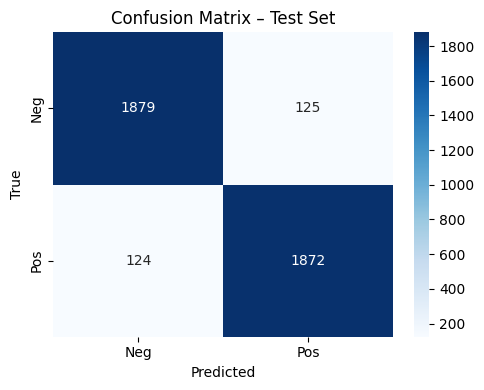

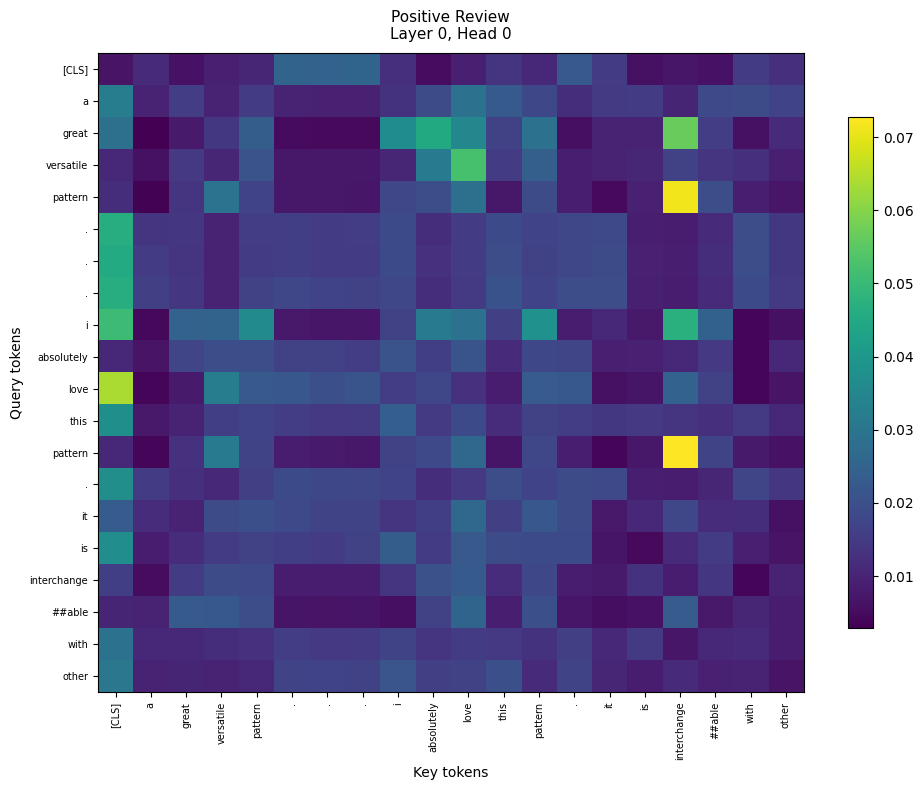

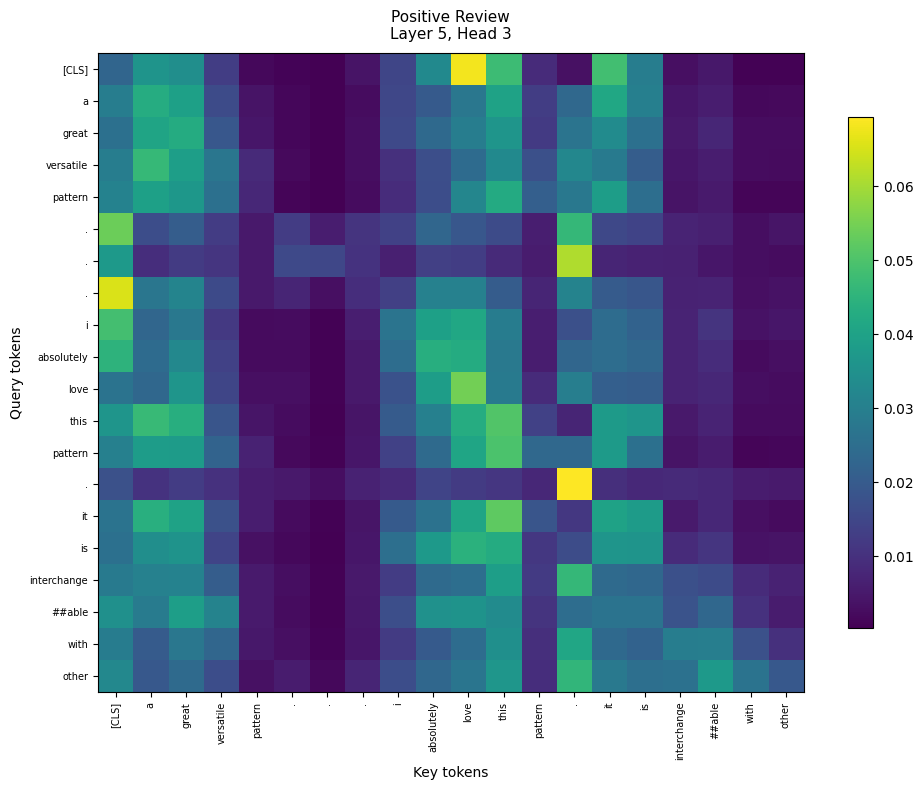

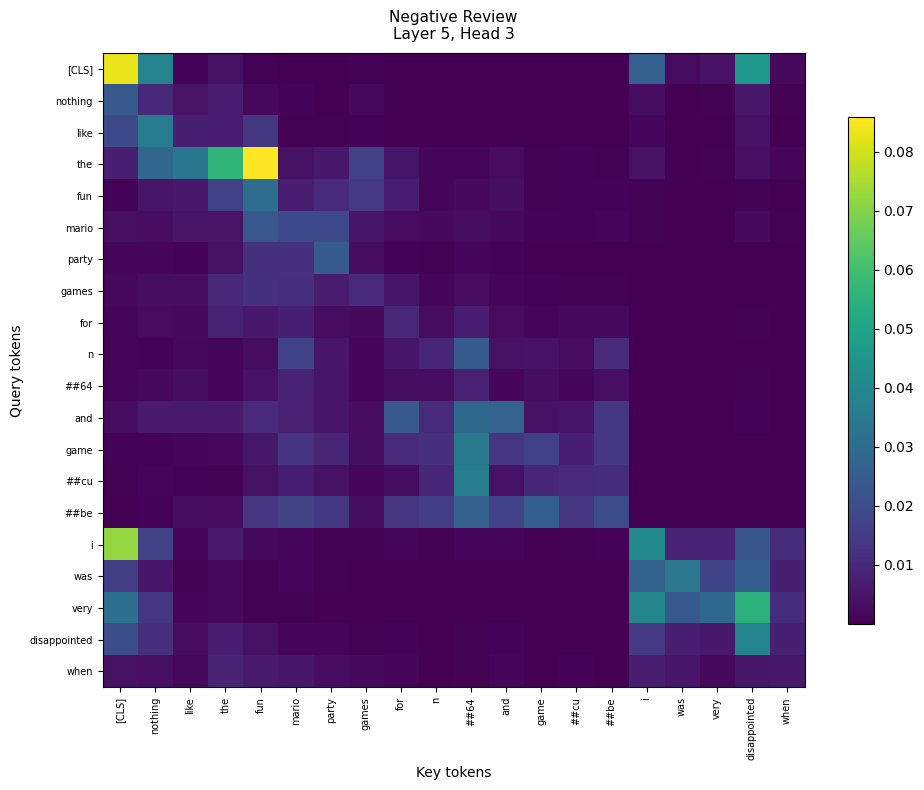

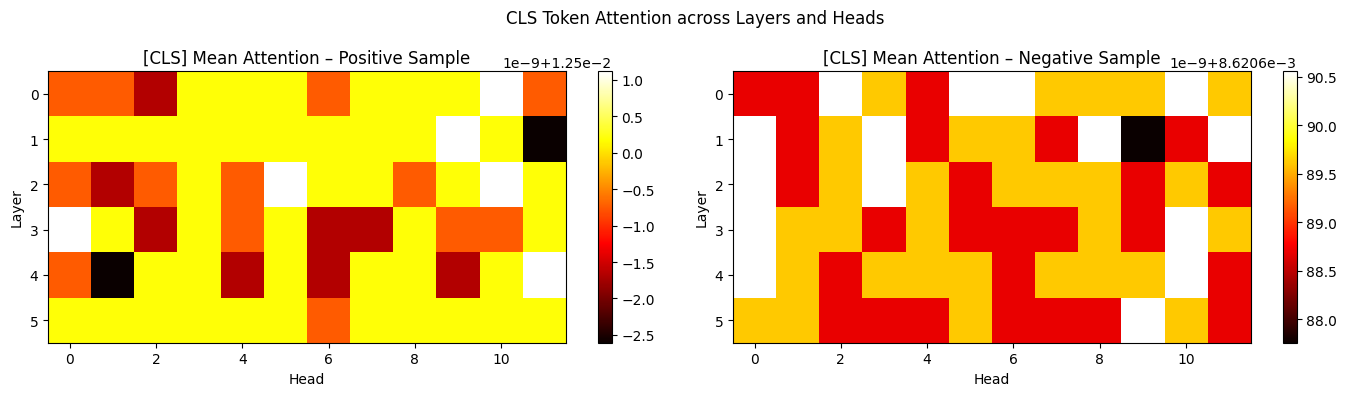

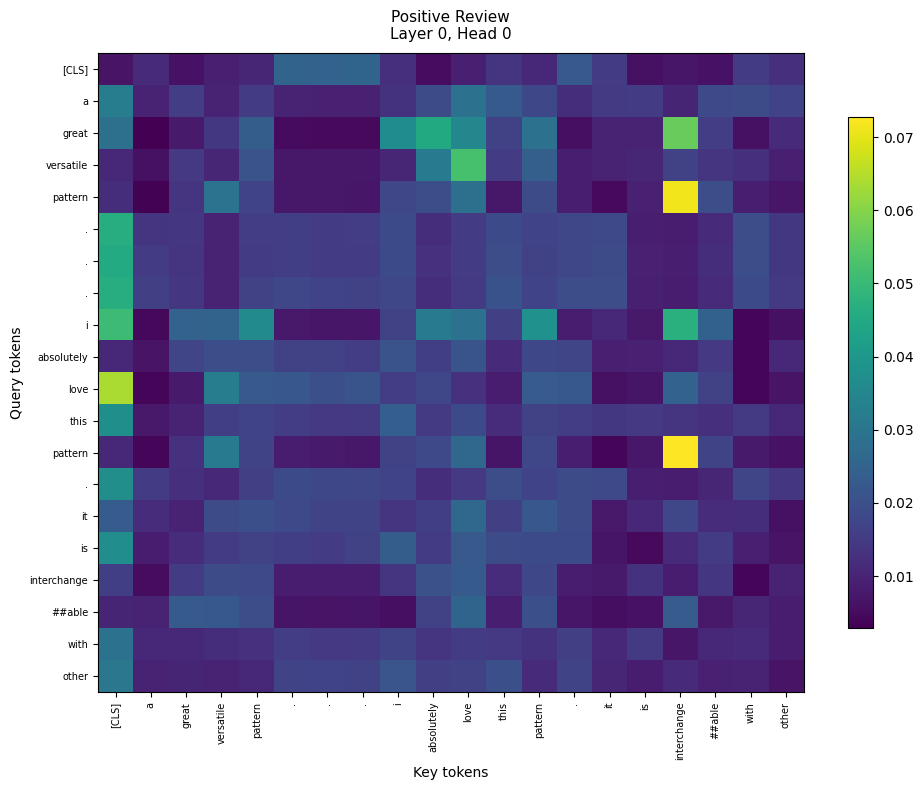

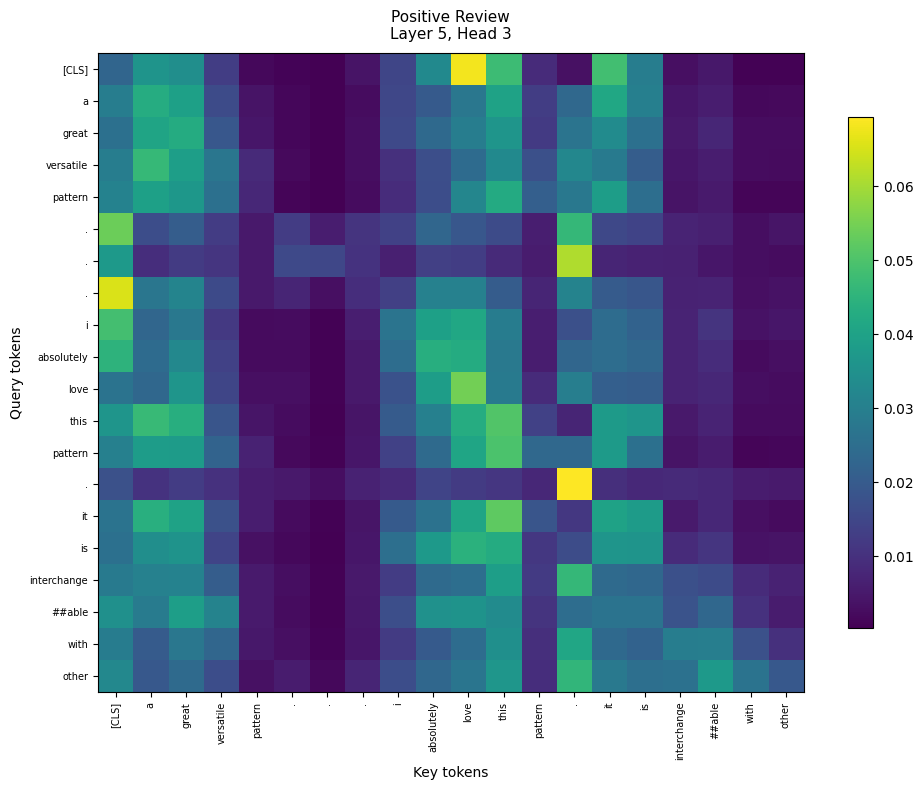

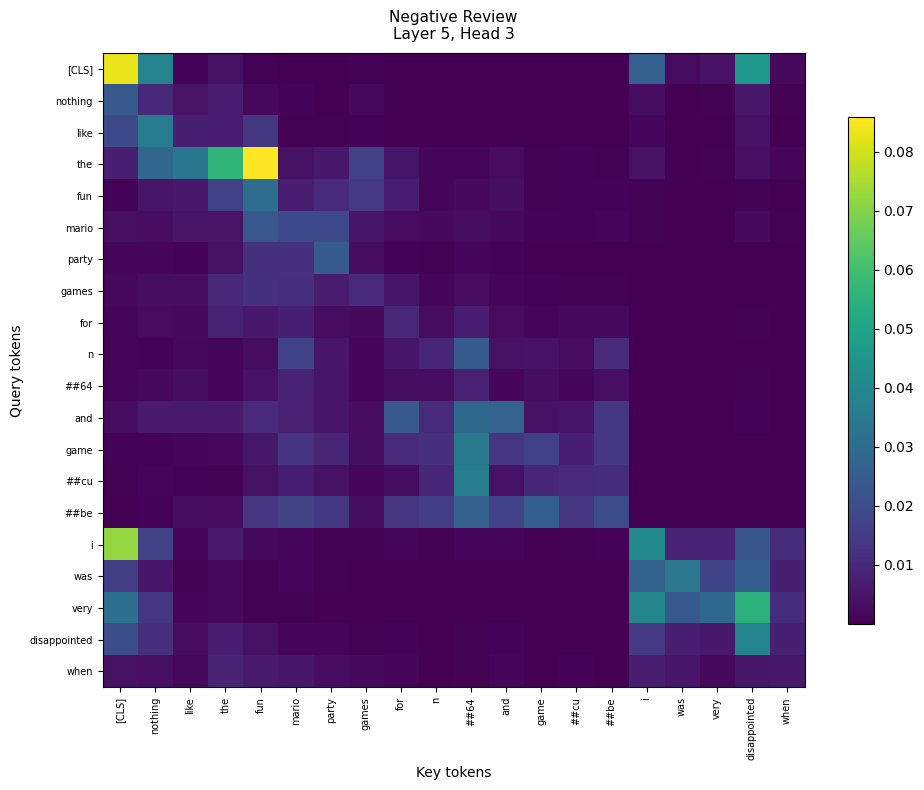

Attention heatmaps saved → figures/


In [19]:
# ─────────────────────────────────────────────
# 9. ATTENTION HEATMAPS — Layer 0 & Layer 5
# ─────────────────────────────────────────────
def plot_attention_heatmap(tokens, attention_matrix, layer, head,
                            title='', filename=None, top_n=20):
    """Plot a single attention head as a heatmap."""
    # Trim to top_n tokens for readability
    n = min(top_n, len(tokens))
    toks = tokens[:n]
    attn = attention_matrix[layer][head][:n, :n]

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attn, cmap='viridis', aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(toks, rotation=90, fontsize=7)
    ax.set_yticklabels(toks, fontsize=7)
    ax.set_title(f'{title}\nLayer {layer}, Head {head}', fontsize=11, pad=10)
    ax.set_xlabel('Key tokens'); ax.set_ylabel('Query tokens')
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# Heatmap 1 — Layer 0, Head 0 (early layer syntactic patterns)
plot_attention_heatmap(
    tokens_pos, attn_pos, layer=0, head=0,
    title='Positive Review', filename=FIG/'attn_L0_H0_positive.png'
)

# Heatmap 2 — Layer 5, Head 3 (late layer semantic patterns)
plot_attention_heatmap(
    tokens_pos, attn_pos, layer=5, head=3,
    title='Positive Review', filename=FIG/'attn_L5_H3_positive.png'
)

# Heatmap 3 — Negative review for contrast
plot_attention_heatmap(
    tokens_neg, attn_neg, layer=5, head=3,
    title='Negative Review', filename=FIG/'attn_L5_H3_negative.png'
)

print("Attention heatmaps saved → figures/")

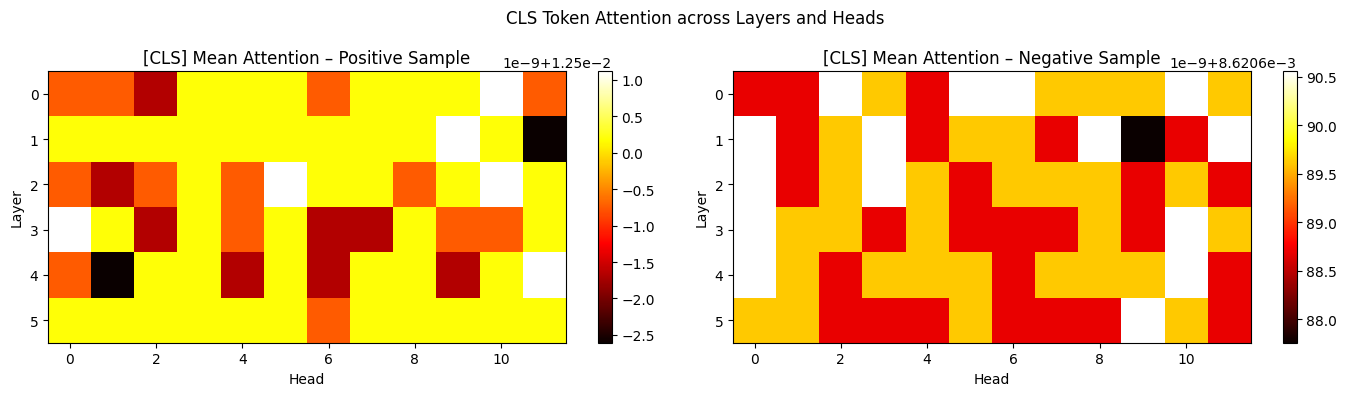

CLS attention grid saved → figures/cls_attention_grid.png


In [20]:
# ─────────────────────────────────────────────
# 10. MEAN ATTENTION PER HEAD (all layers)
# ─────────────────────────────────────────────
def mean_cls_attention(attentions):
    """Return (n_layers, n_heads) matrix: mean attention FROM [CLS] token."""
    result = []
    for layer_attn in attentions:          # (heads, seq, seq)
        cls_row = layer_attn[:, 0, :]      # (heads, seq) – CLS queries
        result.append(cls_row.mean(axis=1))  # mean over tokens → (heads,)
    return np.array(result)

cls_attn_pos = mean_cls_attention(attn_pos)
cls_attn_neg = mean_cls_attention(attn_neg)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in zip(axes,
                            [cls_attn_pos, cls_attn_neg],
                            ['Positive Sample', 'Negative Sample']):
    im = ax.imshow(data, cmap='hot', aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_xlabel('Head'); ax.set_ylabel('Layer')
    ax.set_title(f'[CLS] Mean Attention – {title}')
plt.suptitle('CLS Token Attention across Layers and Heads', fontsize=12)
plt.tight_layout()
plt.savefig(FIG/'cls_attention_grid.png', dpi=150)
plt.show()
print("CLS attention grid saved → figures/cls_attention_grid.png")

In [21]:
# ─────────────────────────────────────────────
# 11. TOP-ATTENDED TOKENS ANALYSIS
# ─────────────────────────────────────────────
def top_tokens_per_head(tokens, attentions, layer, head, top_k=5):
    """Return top-k attended tokens from [CLS] in a given layer/head."""
    attn = attentions[layer][head][0, :]   # CLS row
    top_idx = np.argsort(attn)[::-1][:top_k]
    return [(tokens[i], round(float(attn[i]), 4)) for i in top_idx]

print("=== Top-5 attended tokens (Positive review) ===")
for layer in [0, 2, 5]:
    for head in [0, 3]:
        tops = top_tokens_per_head(tokens_pos, attn_pos, layer, head)
        print(f"  Layer {layer}, Head {head}: {tops}")

print("\n=== Top-5 attended tokens (Negative review) ===")
for layer in [0, 2, 5]:
    for head in [0, 3]:
        tops = top_tokens_per_head(tokens_neg, attn_neg, layer, head)
        print(f"  Layer {layer}, Head {head}: {tops}")

=== Top-5 attended tokens (Positive review) ===
  Layer 0, Head 0: [('.', 0.0297), ('.', 0.0276), ('.', 0.027), ('.', 0.0254), ('.', 0.025)]
  Layer 0, Head 3: [('[CLS]', 0.3082), ('[SEP]', 0.0358), ('a', 0.0222), ('versatile', 0.0216), ('sc', 0.0151)]
  Layer 2, Head 0: [('sets', 0.1492), ('accent', 0.138), ('[SEP]', 0.1314), ('salad', 0.0617), ('set', 0.0492)]
  Layer 2, Head 3: [('[SEP]', 0.9284), ('salad', 0.0142), ('small', 0.0059), ('accent', 0.0054), ('[CLS]', 0.0036)]
  Layer 5, Head 0: [('which', 0.0617), ('which', 0.0403), ('love', 0.0379), ('this', 0.0333), ('[CLS]', 0.0329)]
  Layer 5, Head 3: [('are', 0.0984), ('love', 0.0682), ('it', 0.0485), ('this', 0.0476), ('the', 0.0458)]

=== Top-5 attended tokens (Negative review) ===
  Layer 0, Head 0: [('.', 0.0212), ('.', 0.0209), ('[SEP]', 0.02), ('.', 0.0197), ('.', 0.0196)]
  Layer 0, Head 3: [('[CLS]', 0.2784), ('nothing', 0.0206), ('[SEP]', 0.0206), ('mario', 0.0147), ('the', 0.0135)]
  Layer 2, Head 0: [('missions', 0.1183

---
## Section 4 — SHAP Explainability

In [22]:
# ─────────────────────────────────────────────
# 12. SHAP SETUP
# ─────────────────────────────────────────────
# Use SHAP's Partition (TreeShap-like) explainer for transformers
def shap_predict_fn(texts):
    """Predict function returning probability of POSITIVE class."""
    enc = tokenizer(
        list(texts), return_tensors='pt',
        truncation=True, padding=True, max_length=MAX_LEN
    ).to(DEVICE)
    with torch.no_grad():
        logits = model(**enc).logits
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    return probs

# SHAP Masker for text
masker = shap.maskers.Text(tokenizer=r"\W+")   # word-level masking
shap_explainer = shap.Explainer(shap_predict_fn, masker=masker,
                                 output_names=['Negative', 'Positive'])

# Select 20 test samples (10 pos, 10 neg)
shap_samples_pos = test_df[test_df.label==1].head(10)['content'].tolist()
shap_samples_neg = test_df[test_df.label==0].head(10)['content'].tolist()
shap_texts = shap_samples_pos + shap_samples_neg
print(f"SHAP samples: {len(shap_texts)} (10 positive + 10 negative)")

SHAP samples: 20 (10 positive + 10 negative)


In [23]:
# ─────────────────────────────────────────────
# 13. COMPUTE SHAP VALUES
# ─────────────────────────────────────────────
print("Computing SHAP values (this may take several minutes) …")
t0 = time.time()
shap_values = shap_explainer(shap_texts)
print(f"SHAP computation time: {time.time()-t0:.1f}s")

Computing SHAP values (this may take several minutes) …


PartitionExplainer explainer: 21it [00:21,  1.98s/it]                        

SHAP computation time: 21.8s


=== SHAP Text Plot — Sample 0 (Positive) ===


=== SHAP Text Plot — Sample 10 (Negative) ===


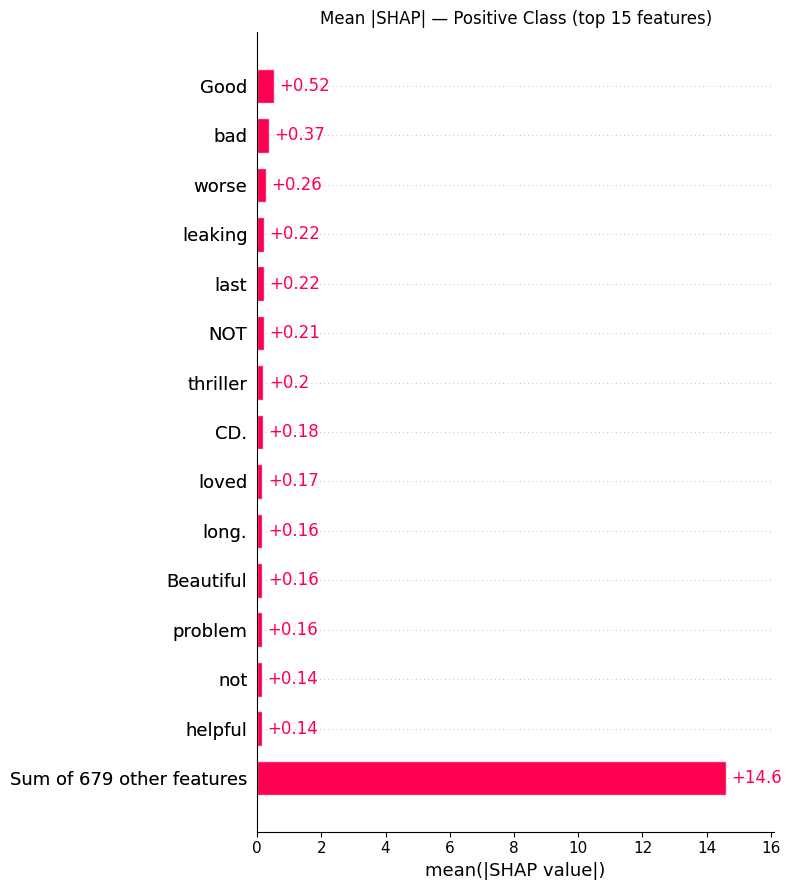

Saved → figures/shap_bar.png


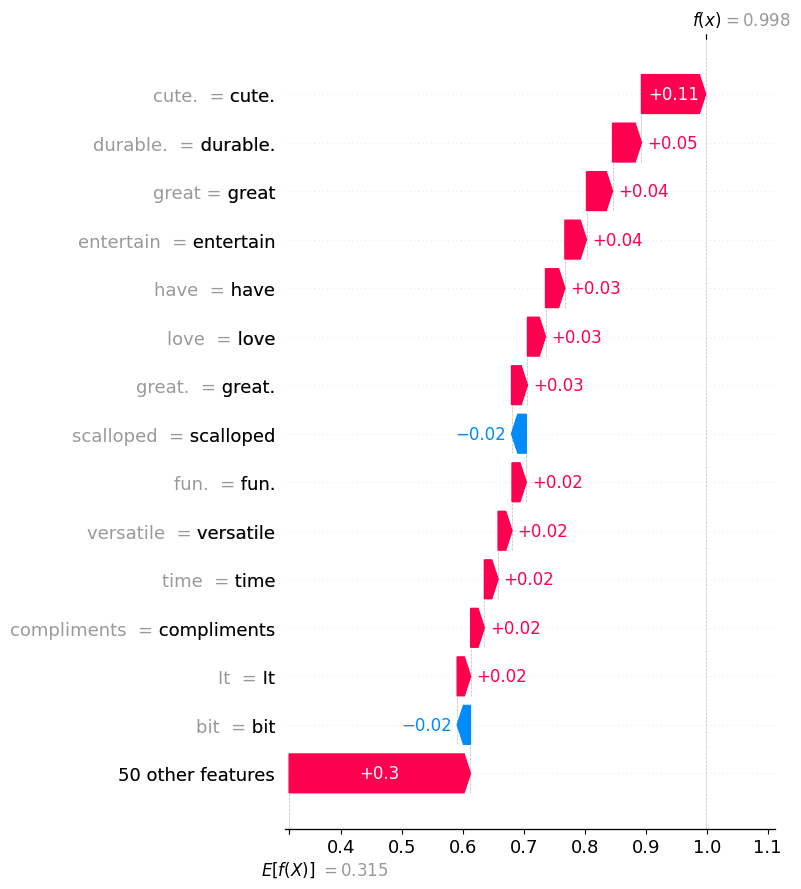

Saved → figures/shap_waterfall_pos.png


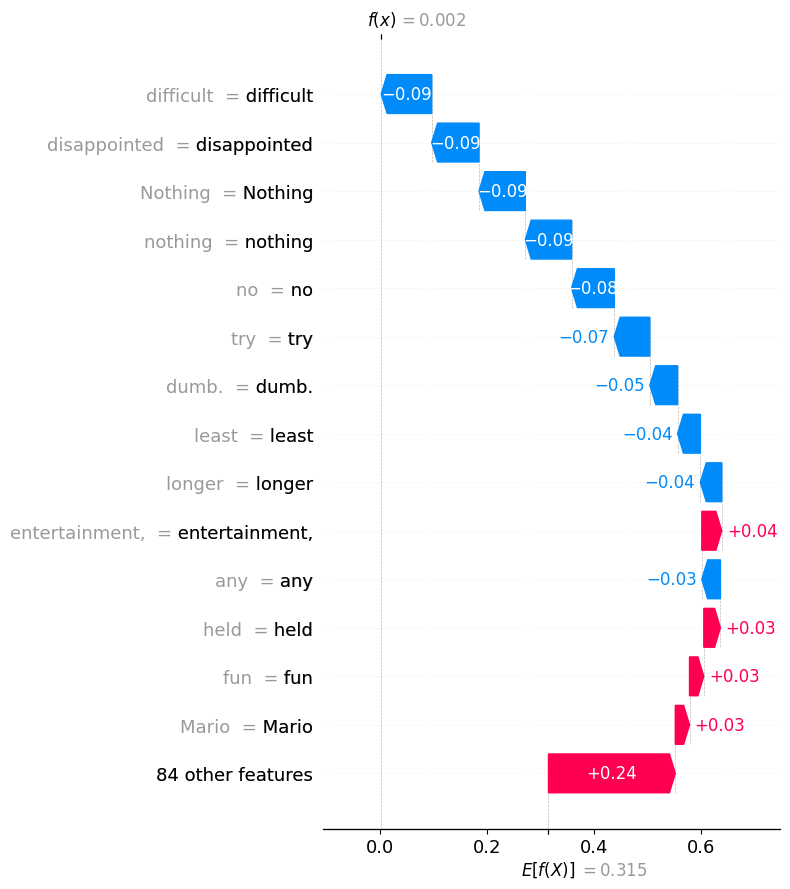

Saved → figures/shap_waterfall_neg.png


In [24]:
# ─────────────────────────────────────────────
# 14. SHAP PLOTS
# ─────────────────────────────────────────────

# --- 14a. Text plot for sample 0 (positive) ---
print("=== SHAP Text Plot — Sample 0 (Positive) ===")
shap.plots.text(shap_values[0, :, 1])   # index 1 = 'Positive' output

# --- 14b. Text plot for sample 10 (negative) ---
print("=== SHAP Text Plot — Sample 10 (Negative) ===")
shap.plots.text(shap_values[10, :, 1])

# --- 14c. Bar chart: mean |SHAP| across all samples (Positive class) ---
shap.plots.bar(shap_values[:, :, 1], max_display=15, show=False)
plt.title('Mean |SHAP| — Positive Class (top 15 features)')
plt.tight_layout()
plt.savefig(FIG/'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/shap_bar.png")

# --- 14d. Waterfall for first positive sample ---
shap.plots.waterfall(shap_values[0, :, 1], max_display=15, show=False)
plt.tight_layout()
plt.savefig(FIG/'shap_waterfall_pos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/shap_waterfall_pos.png")

# --- 14e. Waterfall for first negative sample ---
shap.plots.waterfall(shap_values[10, :, 1], max_display=15, show=False)
plt.tight_layout()
plt.savefig(FIG/'shap_waterfall_neg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/shap_waterfall_neg.png")

In [46]:
import shutil
shutil.copytree('/content/figures', '/content/drive/MyDrive/Assignment4_figures')
print("Done!")

Done!


In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
# ─────────────────────────────────────────────
# 15. SAVE SHAP SUMMARY TABLE (20 samples)
# ─────────────────────────────────────────────
shap_rows = []
for i, txt in enumerate(shap_texts):
    vals = shap_values[i, :, 1].values      # SHAP values for Positive class
    words = shap_values[i, :, 1].data       # the words / tokens
    top3 = sorted(zip(words, vals), key=lambda x: abs(x[1]), reverse=True)[:3]
    pred_prob = float(shap_predict_fn([txt])[0, 1])
    shap_rows.append({
        'sample_idx': i,
        'true_label': 'Positive' if i < 10 else 'Negative',
        'pred_prob_pos': round(pred_prob, 4),
        'top_tokens': ', '.join([f'{w}({v:+.3f})' for w, v in top3]),
        'text_snippet': txt[:80] + '…'
    })

shap_df = pd.DataFrame(shap_rows)
shap_df.to_csv(OUT/'shap_explanations_20.csv', index=False)
print(shap_df.to_string(index=False))
print("\nSaved → outputs/shap_explanations_20.csv")

 sample_idx true_label  pred_prob_pos                                                  top_tokens                                                                      text_snippet
          0   Positive         0.9983            cute. (+0.105), durable. (+0.047), great(+0.043) A great versatile pattern... I absolutely love this pattern. It is interchangeab…
          1   Positive         0.9966              Good (+0.516), thriller (+0.195), but (-0.139) Good thriller set against a series of coincidences Margolin comes through with a…
          2   Positive         0.9975                no (-0.098), authority (+0.078), no (-0.074) The Cure ~ The Cure Robert Smith always looks like he is about to loose his mind…
          3   Positive         0.9975              loved (+0.165), helpful (+0.142), new (+0.050) For my Grandson A friend loaned me a thirty-year old copy of Nineteen Stars and …
          4   Positive         0.9978              rich (+0.093), heart. (+0.068), break (-0.058) A 

---
## Section 5 — LIME Explainability

In [26]:
# ─────────────────────────────────────────────
# 16. LIME SETUP
# ─────────────────────────────────────────────
lime_explainer = LimeTextExplainer(
    class_names=['Negative', 'Positive'],
    random_state=SEED,
)

def lime_predict_fn(texts):
    """LIME expects a 2-class probability array."""
    return shap_predict_fn(texts)    # reuses our predict fn

# Use the same 20 samples as SHAP for direct comparison
lime_texts = shap_texts  # 20 samples
print(f"LIME samples: {len(lime_texts)}")

LIME samples: 20


In [27]:
# ─────────────────────────────────────────────
# 17. COMPUTE LIME EXPLANATIONS (all 20 samples)
# ─────────────────────────────────────────────
NUM_FEATURES = 10
NUM_SAMPLES  = 300   # perturbation samples per explanation

lime_results = []
lime_times   = []

print("Computing LIME explanations …")
for i, txt in enumerate(lime_texts):
    t0 = time.time()
    exp = lime_explainer.explain_instance(
        txt,
        lime_predict_fn,
        num_features=NUM_FEATURES,
        num_samples=NUM_SAMPLES,
        labels=[1],   # Positive class
    )
    elapsed = time.time() - t0
    lime_times.append(elapsed)
    lime_results.append(exp)
    print(f"  [{i+1:02d}/20] {elapsed:.1f}s  pred={exp.predict_proba[1]:.3f}")

print(f"\nTotal LIME time: {sum(lime_times):.1f}s  | Mean per sample: {np.mean(lime_times):.1f}s")

Computing LIME explanations …
  [01/20] 0.3s  pred=0.998
  [02/20] 0.3s  pred=0.997
  [03/20] 0.4s  pred=0.998
  [04/20] 0.4s  pred=0.998
  [05/20] 0.5s  pred=0.998
  [06/20] 0.6s  pred=0.998
  [07/20] 0.2s  pred=0.996
  [08/20] 0.4s  pred=0.997
  [09/20] 0.1s  pred=0.998
  [10/20] 0.2s  pred=0.998
  [11/20] 0.4s  pred=0.002
  [12/20] 0.3s  pred=0.018
  [13/20] 0.3s  pred=0.009
  [14/20] 0.2s  pred=0.021
  [15/20] 0.4s  pred=0.011
  [16/20] 0.4s  pred=0.019
  [17/20] 0.1s  pred=0.009
  [18/20] 0.1s  pred=0.002
  [19/20] 0.4s  pred=0.001
  [20/20] 0.2s  pred=0.001

Total LIME time: 6.5s  | Mean per sample: 0.3s


LIME HTML saved → outputs/lime_sample_0.html
LIME HTML saved → outputs/lime_sample_10.html


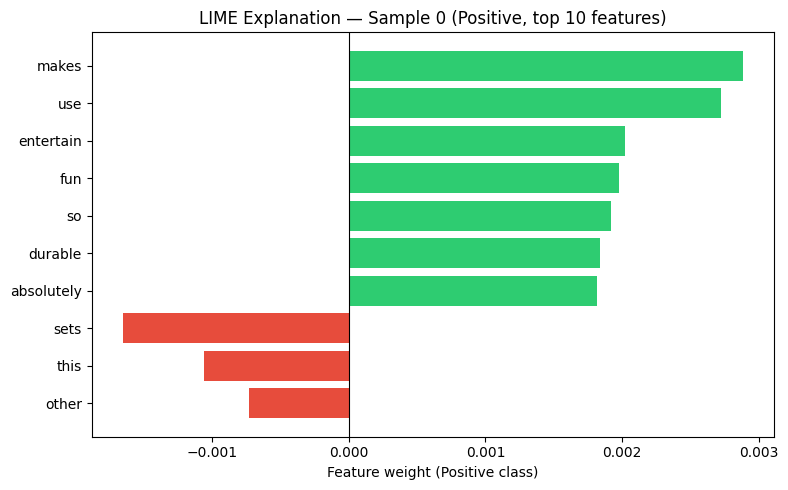

Saved → figures/lime_bar_sample0.png


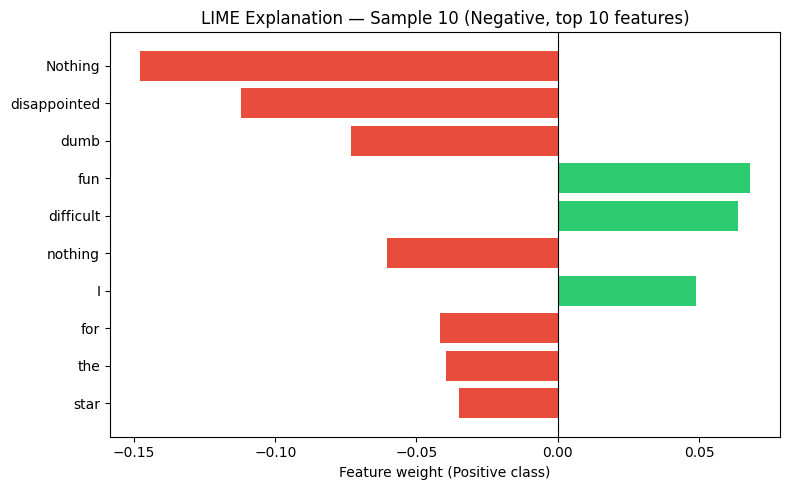

Saved → figures/lime_bar_sample10.png


In [28]:
# ─────────────────────────────────────────────
# 18. LIME VISUALISATION
# ─────────────────────────────────────────────

# Save HTML explanations for first 3 samples
for i in [0, 10]:   # one positive, one negative
    html = lime_results[i].as_html()
    fname = OUT / f'lime_sample_{i}.html'
    fname.write_text(html)
    print(f"LIME HTML saved → {fname}")

# Bar-chart visualization for sample 0
exp = lime_results[0]
weights = dict(exp.as_list(label=1))
words_sorted = sorted(weights, key=lambda w: abs(weights[w]), reverse=True)[:10]
scores = [weights[w] for w in words_sorted]
colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in scores]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(words_sorted[::-1], scores[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('LIME Explanation — Sample 0 (Positive, top 10 features)')
ax.set_xlabel('Feature weight (Positive class)')
plt.tight_layout()
plt.savefig(FIG/'lime_bar_sample0.png', dpi=150)
plt.show()
print("Saved → figures/lime_bar_sample0.png")

# Bar-chart for negative sample
exp10 = lime_results[10]
weights10 = dict(exp10.as_list(label=1))
words10 = sorted(weights10, key=lambda w: abs(weights10[w]), reverse=True)[:10]
scores10 = [weights10[w] for w in words10]
colors10 = ['#2ecc71' if s > 0 else '#e74c3c' for s in scores10]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(words10[::-1], scores10[::-1], color=colors10[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('LIME Explanation — Sample 10 (Negative, top 10 features)')
ax.set_xlabel('Feature weight (Positive class)')
plt.tight_layout()
plt.savefig(FIG/'lime_bar_sample10.png', dpi=150)
plt.show()
print("Saved → figures/lime_bar_sample10.png")

In [29]:
# ─────────────────────────────────────────────
# 19. SAVE LIME SUMMARY TABLE (20 samples)
# ─────────────────────────────────────────────
lime_rows = []
for i, (exp, elapsed) in enumerate(zip(lime_results, lime_times)):
    top3 = exp.as_list(label=1)[:3]
    lime_rows.append({
        'sample_idx': i,
        'true_label': 'Positive' if i < 10 else 'Negative',
        'pred_prob_pos': round(exp.predict_proba[1], 4),
        'top_tokens': ', '.join([f'{w}({v:+.3f})' for w, v in top3]),
        'runtime_s': round(elapsed, 2),
        'text_snippet': lime_texts[i][:80] + '…'
    })

lime_df = pd.DataFrame(lime_rows)
lime_df.to_csv(OUT/'lime_explanations_20.csv', index=False)
print(lime_df.to_string(index=False))
print("\nSaved → outputs/lime_explanations_20.csv")

 sample_idx true_label  pred_prob_pos                                             top_tokens  runtime_s                                                                      text_snippet
          0   Positive         0.9983          makes(+0.003), use(+0.003), entertain(+0.002)       0.32 A great versatile pattern... I absolutely love this pattern. It is interchangeab…
          1   Positive         0.9966        Good(+0.199), thriller(+0.182), through(+0.078)       0.35 Good thriller set against a series of coincidences Margolin comes through with a…
          2   Positive         0.9975   accomplished(+0.077), groove(+0.058), lyrics(-0.037)       0.42 The Cure ~ The Cure Robert Smith always looks like he is about to loose his mind…
          3   Positive         0.9975           friend(+0.021), loaned(-0.021), Army(-0.016)       0.41 For my Grandson A friend loaned me a thirty-year old copy of Nineteen Stars and …
          4   Positive         0.9978          but(+0.037), rich(+0.03

---
## Section 6 — Comparative Analysis: SHAP vs LIME

In [30]:
# ─────────────────────────────────────────────
# 20. FAITHFULNESS (prediction fidelity)
# Remove top-K features and measure prediction flip rate
# ─────────────────────────────────────────────

def mask_top_features(text, top_features, method='shap'):
    """Replace top features with [MASK] and return masked text."""
    masked = text
    for feat in top_features:
        word = feat[0] if method == 'lime' else str(feat[0])
        masked = re.sub(r'\b' + re.escape(word) + r'\b', '[MASK]', masked, flags=re.IGNORECASE)
    return masked

def faithfulness_score(texts, explanations, method='shap', top_k=3):
    """Fraction of cases where removing top features changes the predicted class."""
    flips = 0
    for i, txt in enumerate(texts):
        orig_pred = int(shap_predict_fn([txt])[0, 1] > 0.5)
        if method == 'shap':
            sv   = explanations[i, :, 1]
            tops = sorted(zip(sv.data, sv.values), key=lambda x: abs(x[1]), reverse=True)[:top_k]
            top_features = tops
        else:
            top_features = explanations[i].as_list(label=1)[:top_k]
        masked = mask_top_features(txt, top_features, method)
        masked_pred = int(shap_predict_fn([masked])[0, 1] > 0.5)
        if orig_pred != masked_pred:
            flips += 1
    return flips / len(texts)

print("Computing faithfulness (this may take ~1 min) …")
faith_shap = faithfulness_score(shap_texts, shap_values, method='shap', top_k=3)
faith_lime = faithfulness_score(lime_texts, lime_results, method='lime', top_k=3)
print(f"Faithfulness (flip rate, top-3 features):")
print(f"  SHAP: {faith_shap:.3f}")
print(f"  LIME: {faith_lime:.3f}")

Computing faithfulness (this may take ~1 min) …
Faithfulness (flip rate, top-3 features):
  SHAP: 0.150
  LIME: 0.300


In [31]:
# ─────────────────────────────────────────────
# 21. STABILITY (re-run LIME twice, measure overlap)
# SHAP is deterministic; we test LIME stability only
# ─────────────────────────────────────────────

def lime_stability(texts, n_runs=2, top_k=5):
    """Jaccard similarity of top-k features across n_runs for each text."""
    run_features = []
    for _ in range(n_runs):
        run = []
        for txt in texts[:5]:   # subset for speed
            exp = lime_explainer.explain_instance(
                txt, lime_predict_fn,
                num_features=top_k, num_samples=200, labels=[1])
            run.append(set(w for w, _ in exp.as_list(label=1)))
        run_features.append(run)

    jaccard_scores = []
    for j in range(len(texts[:5])):
        a, b = run_features[0][j], run_features[1][j]
        if len(a | b) == 0:
            jaccard_scores.append(1.0)
        else:
            jaccard_scores.append(len(a & b) / len(a | b))
    return np.mean(jaccard_scores)

print("Computing LIME stability (2 runs × 5 samples) …")
lime_stability_score = lime_stability(lime_texts)
print(f"LIME Stability (Jaccard): {lime_stability_score:.3f}")
print(f"SHAP Stability: 1.000 (deterministic given same input)")

Computing LIME stability (2 runs × 5 samples) …
LIME Stability (Jaccard): 0.094
SHAP Stability: 1.000 (deterministic given same input)


Method  Mean time per sample (s)  Faithfulness (flip rate)  Stability (Jaccard)             Deterministic          Scope Interpretability level
  SHAP                      1.01                      0.15                1.000                       Yes Global + Local             Token/word
  LIME                      0.40                      0.30                0.094 No (random perturbations)     Local only                   Word


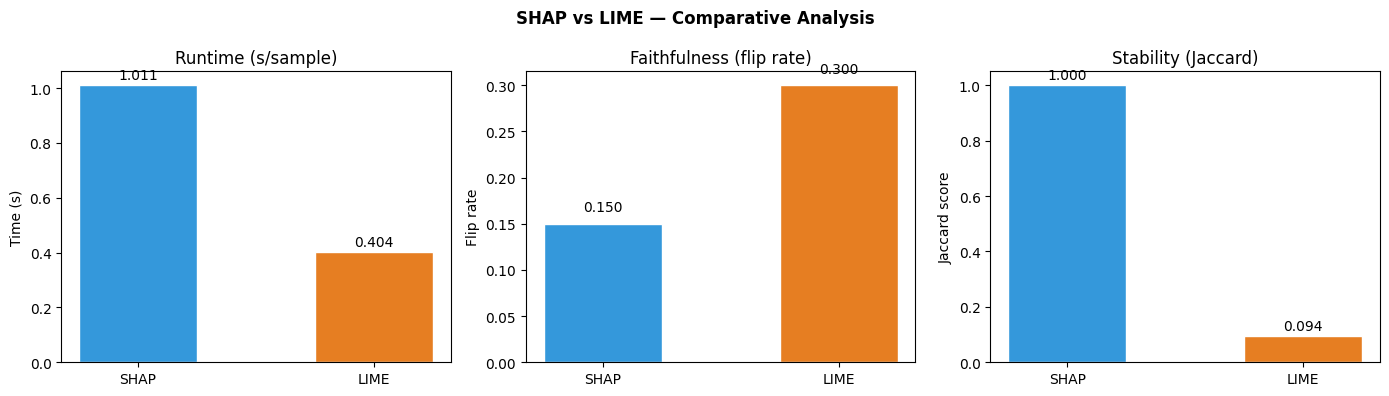

Comparison saved → figures/shap_lime_comparison.png


In [32]:
# ─────────────────────────────────────────────
# 22. RUNTIME COMPARISON
# ─────────────────────────────────────────────

# SHAP timing (5 samples)
shap_times = []
for txt in shap_texts[:5]:
    t0 = time.time()
    shap_explainer([txt])
    shap_times.append(time.time() - t0)

# LIME timing (already stored in lime_times)
comparison = {
    'Method': ['SHAP', 'LIME'],
    'Mean time per sample (s)': [
        round(np.mean(shap_times), 2),
        round(np.mean(lime_times[:5]), 2)
    ],
    'Faithfulness (flip rate)': [round(faith_shap, 3), round(faith_lime, 3)],
    'Stability (Jaccard)'      : [1.0, round(lime_stability_score, 3)],
    'Deterministic'            : ['Yes', 'No (random perturbations)'],
    'Scope'                    : ['Global + Local', 'Local only'],
    'Interpretability level'   : ['Token/word', 'Word'],
}

comp_df = pd.DataFrame(comparison)
comp_df.to_csv(OUT/'shap_lime_comparison.csv', index=False)
print(comp_df.to_string(index=False))

# Bar chart: runtime comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_vals = [
    ([np.mean(shap_times), np.mean(lime_times[:5])], 'Runtime (s/sample)', 'Time (s)'),
    ([faith_shap, faith_lime], 'Faithfulness (flip rate)', 'Flip rate'),
    ([1.0, lime_stability_score], 'Stability (Jaccard)', 'Jaccard score'),
]
for ax, (vals, title, ylabel) in zip(axes, metrics_vals):
    bars = ax.bar(['SHAP', 'LIME'], vals, color=['#3498db', '#e67e22'], width=0.5, edgecolor='white')
    ax.set_title(title); ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.suptitle('SHAP vs LIME — Comparative Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG/'shap_lime_comparison.png', dpi=150)
plt.show()
print("Comparison saved → figures/shap_lime_comparison.png")

---
## Section 7 — Error Analysis

In [33]:
# ─────────────────────────────────────────────
# 23. IDENTIFY MISCLASSIFIED SAMPLES
# ─────────────────────────────────────────────
pred_labels = y_pred
true_labels = y_true
test_texts  = test_df['content'].tolist()

# Indices of misclassified samples
errors_idx  = np.where(pred_labels != true_labels)[0]
error_rate  = len(errors_idx) / len(true_labels)
print(f"Total errors: {len(errors_idx)}  /  {len(true_labels)}  ({error_rate*100:.1f}%)")

# False positives and false negatives
fp_idx = np.where((pred_labels==1) & (true_labels==0))[0]
fn_idx = np.where((pred_labels==0) & (true_labels==1))[0]
print(f"False Positives (predicted Pos, true Neg): {len(fp_idx)}")
print(f"False Negatives (predicted Neg, true Pos): {len(fn_idx)}")

# Build error DataFrame
error_records = []
for idx in errors_idx[:30]:   # first 30 errors
    pred_probs = shap_predict_fn([test_texts[idx]])[0]
    error_records.append({
        'idx': idx,
        'true_label': 'Positive' if true_labels[idx]==1 else 'Negative',
        'pred_label': 'Positive' if pred_labels[idx]==1 else 'Negative',
        'confidence': round(max(pred_probs), 4),
        'text_snippet': test_texts[idx][:120] + '…'
    })

error_df = pd.DataFrame(error_records)
error_df.to_csv(OUT/'error_analysis.csv', index=False)
print("\nSample errors:")
print(error_df.head(5).to_string(index=False))

Total errors: 249  /  4000  (6.2%)
False Positives (predicted Pos, true Neg): 125
False Negatives (predicted Neg, true Pos): 124

Sample errors:
 idx true_label pred_label  confidence                                                                                                              text_snippet
  45   Negative   Positive      0.9466 Well written but that's about it Slow paced until two-thirds into the story, much time unnecessarily spent on Creasy's p…
  69   Positive   Negative      0.9983 An all-around "ok" book This book upped my average a little and gave me some helpful tips, but it is so outdated that 80…
  82   Negative   Positive      0.8079 Not bad, not great.... As other reviewers have stated, this is a good book for a broad, superficial review, however, the…
 119   Positive   Negative      0.5668 Once a Slytherin... when the Harry Potter movies and books were released origionally, i was too young to watch them or r…
 143   Positive   Negative      0.9781 An Inconven

Explaining misclassified samples with LIME …


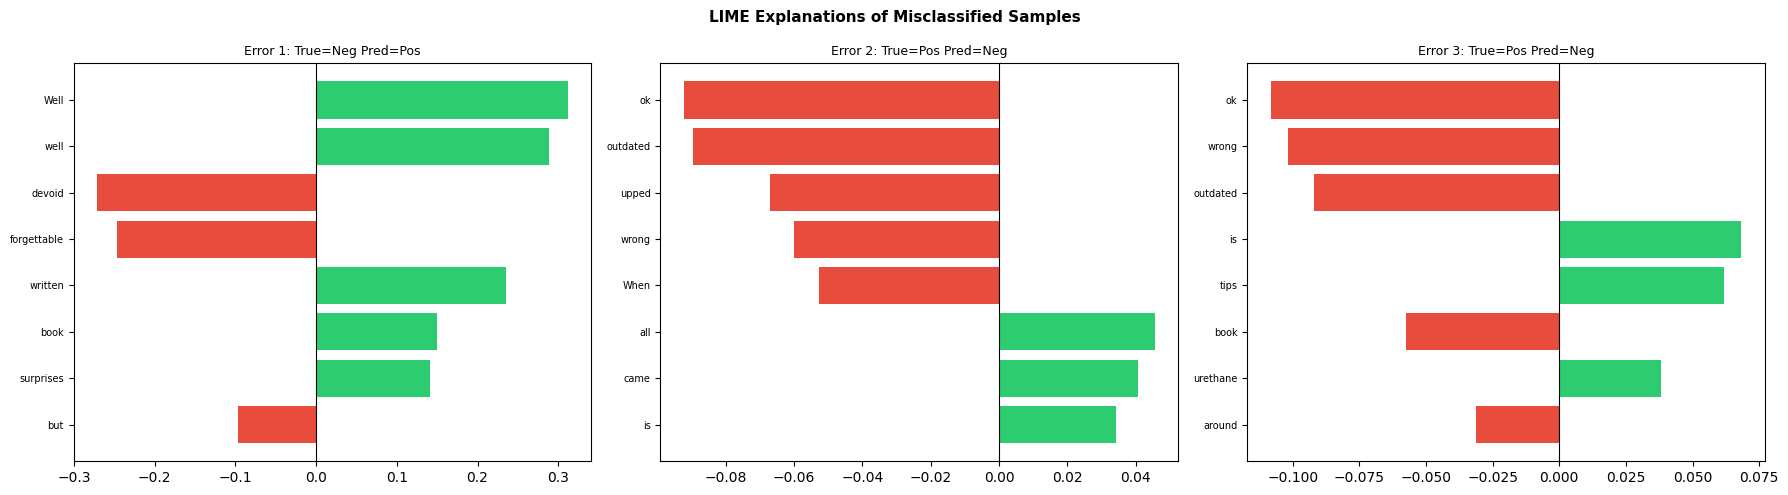

Saved → figures/error_lime_explanations.png


In [34]:
# ─────────────────────────────────────────────
# 24. EXPLAIN ERROR SAMPLES WITH LIME
# ─────────────────────────────────────────────
# Pick 3 errors: 1 FP, 1 FN, 1 high-confidence error
error_sample_idx = [fp_idx[0], fn_idx[0], errors_idx[np.argmax(
    [max(shap_predict_fn([test_texts[i]])[0]) for i in errors_idx[:20]]
)]]

print("Explaining misclassified samples with LIME …")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for plot_i, (sample_i, ax) in enumerate(zip(error_sample_idx, axes)):
    txt = test_texts[sample_i]
    exp = lime_explainer.explain_instance(
        txt, lime_predict_fn, num_features=8, num_samples=200, labels=[1])
    weights_d = dict(exp.as_list(label=1))
    words = sorted(weights_d, key=lambda w: abs(weights_d[w]), reverse=True)[:8]
    scores_l = [weights_d[w] for w in words]
    bar_colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in scores_l]

    ax.barh(words[::-1], scores_l[::-1], color=bar_colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    true_l = 'Pos' if true_labels[sample_i]==1 else 'Neg'
    pred_l = 'Pos' if pred_labels[sample_i]==1 else 'Neg'
    ax.set_title(f'Error {plot_i+1}: True={true_l} Pred={pred_l}', fontsize=9)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('LIME Explanations of Misclassified Samples', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG/'error_lime_explanations.png', dpi=150)
plt.show()
print("Saved → figures/error_lime_explanations.png")

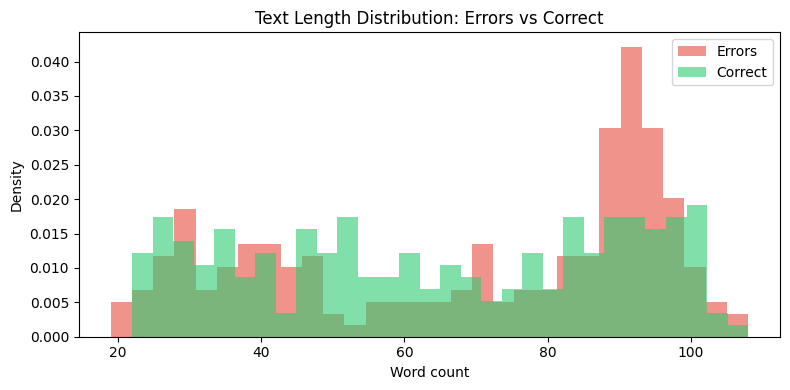

Mean word count — Errors: 69.5 | Correct: 64.4
Saved → figures/error_length_analysis.png


In [35]:
# ─────────────────────────────────────────────
# 25. ERROR PATTERN ANALYSIS
# Common causes: sarcasm, short text, mixed sentiment
# ─────────────────────────────────────────────

# Length analysis: errors vs correct
correct_idx = np.where(pred_labels == true_labels)[0]
error_lengths   = [len(test_texts[i].split()) for i in errors_idx[:200]]
correct_lengths = [len(test_texts[i].split()) for i in correct_idx[:200]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(error_lengths,   bins=30, alpha=0.6, color='#e74c3c', label='Errors',  density=True)
ax.hist(correct_lengths, bins=30, alpha=0.6, color='#2ecc71', label='Correct', density=True)
ax.set(title='Text Length Distribution: Errors vs Correct',
       xlabel='Word count', ylabel='Density')
ax.legend()
plt.tight_layout()
plt.savefig(FIG/'error_length_analysis.png', dpi=150)
plt.show()
print(f"Mean word count — Errors: {np.mean(error_lengths):.1f} | Correct: {np.mean(correct_lengths):.1f}")
print("Saved → figures/error_length_analysis.png")

---
## Section 8 — Summary & Methodology Flowchart

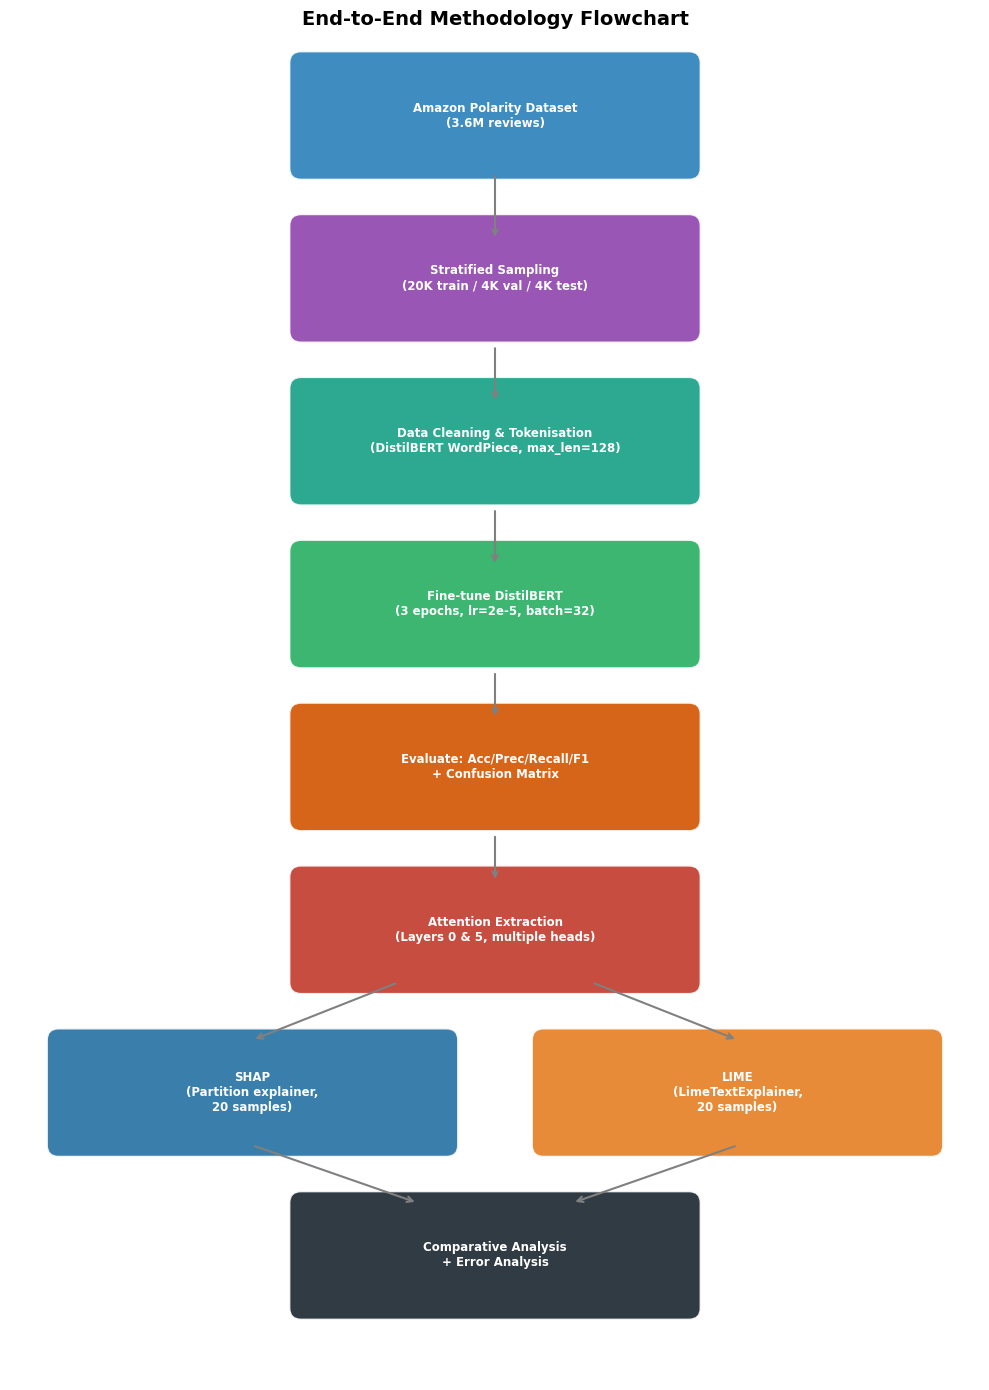

Flowchart saved → figures/methodology_flowchart.png


In [36]:
# ─────────────────────────────────────────────
# 26. METHODOLOGY FLOWCHART (matplotlib)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 14))
ax.set_xlim(0, 10); ax.set_ylim(0, 14)
ax.axis('off')

steps = [
    (5, 13.2, 'Amazon Polarity Dataset\n(3.6M reviews)',          '#2980b9'),
    (5, 11.5, 'Stratified Sampling\n(20K train / 4K val / 4K test)', '#8e44ad'),
    (5,  9.8, 'Data Cleaning & Tokenisation\n(DistilBERT WordPiece, max_len=128)', '#16a085'),
    (5,  8.1, 'Fine-tune DistilBERT\n(3 epochs, lr=2e-5, batch=32)', '#27ae60'),
    (5,  6.4, 'Evaluate: Acc/Prec/Recall/F1\n+ Confusion Matrix',   '#d35400'),
    (5,  4.7, 'Attention Extraction\n(Layers 0 & 5, multiple heads)', '#c0392b'),
    (2.5, 3.0,'SHAP\n(Partition explainer,\n20 samples)',           '#2471a3'),
    (7.5, 3.0,'LIME\n(LimeTextExplainer,\n20 samples)',             '#e67e22'),
    (5,  1.3, 'Comparative Analysis\n+ Error Analysis',             '#1a252f'),
]

for x, y, label, color in steps:
    rect = mpatches.FancyBboxPatch((x-2.0, y-0.55), 4.0, 1.1,
        boxstyle='round,pad=0.12', linewidth=1.5,
        edgecolor='white', facecolor=color, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold')

# Arrows (vertical)
arrow_xs = [5, 5, 5, 5, 5]
arrow_ys = [(12.6,11.9), (10.8,10.2), (9.1,8.5), (7.4,6.9), (5.7,5.2)]
for ax_x, (y1, y2) in zip(arrow_xs, arrow_ys):
    ax.annotate('', xy=(ax_x, y2), xytext=(ax_x, y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Arrow from step 5 to SHAP and LIME
ax.annotate('', xy=(2.5, 3.55), xytext=(4.0, 4.15),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.annotate('', xy=(7.5, 3.55), xytext=(6.0, 4.15),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Arrows from SHAP/LIME to comparison
ax.annotate('', xy=(4.2, 1.85), xytext=(2.5, 2.45),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.annotate('', xy=(5.8, 1.85), xytext=(7.5, 2.45),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_title('End-to-End Methodology Flowchart', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(FIG/'methodology_flowchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Flowchart saved → figures/methodology_flowchart.png")

In [37]:
# ─────────────────────────────────────────────
# 27. FINAL RESULTS SUMMARY
# ─────────────────────────────────────────────
final_metrics = pd.read_csv(OUT/'test_metrics.csv')
print("="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"Model          : DistilBERT (fine-tuned)")
print(f"Dataset        : Amazon Polarity (subset)")
print(f"Train samples  : {TRAIN_SIZE:,}")
print(f"Test samples   : {TEST_SIZE:,}")
print()
for col in final_metrics.columns:
    print(f"  {col:12s}: {final_metrics[col].iloc[0]:.4f}")
print()
print(f"SHAP (mean runtime/sample) : {np.mean(shap_times):.2f}s")
print(f"LIME (mean runtime/sample) : {np.mean(lime_times):.2f}s")
print(f"SHAP Faithfulness          : {faith_shap:.3f}")
print(f"LIME Faithfulness          : {faith_lime:.3f}")
print(f"LIME Stability (Jaccard)   : {lime_stability_score:.3f}")
print("="*50)
print("All outputs saved in ./outputs/ and ./figures/")

FINAL RESULTS SUMMARY
Model          : DistilBERT (fine-tuned)
Dataset        : Amazon Polarity (subset)
Train samples  : 20,000
Test samples   : 4,000

  Accuracy    : 0.9377
  Precision   : 0.9374
  Recall      : 0.9379
  F1          : 0.9376

SHAP (mean runtime/sample) : 1.01s
LIME (mean runtime/sample) : 0.32s
SHAP Faithfulness          : 0.150
LIME Faithfulness          : 0.300
LIME Stability (Jaccard)   : 0.094
All outputs saved in ./outputs/ and ./figures/
